# Extracción de Variables Climáticas y Oceanográficas ERA5 usando GEE

Este Notebook permite extraer series de tiempo estacionales de **temperatura superficial del mar (SST)**, **dirección y velocidad del viento**, y **altura y dirección dominante de olas** a partir de la base de datos global **ERA5 Hourly (ECMWF/ERA5/HOURLY)** en Google Earth Engine (GEE).

Para mantener una coincidencia temporal exacta con el análisis de la línea de costa realizado en **CoastSat**, el script lee las fechas del archivo de promedios estacionales (`promedios_estacionales.csv`), define las ventanas de tiempo trimestrales correspondientes y extrae los promedios espaciales sobre el océano frente a el área de estudio.


### 1. Importación de Librerías y Dependencias
Procesamiento de datos (`pandas`, `numpy`), lectura de formatos espaciales (`json`, `os`) e interacción con Google Earth Engine (`ee`).

In [37]:
import os
import json
import datetime
import pandas as pd
import numpy as np
import ee

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


### 2. Variables de Entrada y Configuración

Para analizar otros proyectos, solo cambiar el nombre del sitio en la variable `SITENAME` y asegurarse de que las rutas relativas correspondan a los archivos GeoJSON y CSV. 

In [ ]:
# Nombre del proyecto/sitio activo bajo análisis
SITENAME = 'RBMN_1'

# 1. Ruta al archivo GeoJSON que define el Área de Interés (AOI)
GEOJSON_PATH = os.path.join('proyectos', 'rbmn_1_mar.geojson')

# 2. Ruta al archivo CSV con los promedios estacionales de CoastSat (para tomar el eje temporal)
COASTSAT_CSV_PATH = os.path.join('data', SITENAME, f'{SITENAME}_promedios_estacionales.csv')

# 3. Nombre del proyecto de Google Cloud configurado GEE, cambiar según corresponda
GEE_PROJECT = 'ee-smmm-24'

# 4. Carpeta de destino donde se guardarán los resultados
OUTPUT_DIR = os.path.join('data', SITENAME)

# Verificación rápida de la existencia de los archivos de entrada
print(f"📂 Configurando el proyecto: {SITENAME}")
print(f"📍 Ruta del GeoJSON (AOI): {GEOJSON_PATH} -> {'✅ Encontrado' if os.path.exists(GEOJSON_PATH) else '❌ NO ENCONTRADO'}")
print(f"📊 Ruta del CSV CoastSat:  {COASTSAT_CSV_PATH} -> {'✅ Encontrado' if os.path.exists(COASTSAT_CSV_PATH) else '❌ NO ENCONTRADO'}")

📂 Configurando el proyecto: RBMN_1
📍 Ruta del GeoJSON (AOI): proyectos\rbmn_1_mar.geojson -> ✅ Encontrado
📊 Ruta del CSV CoastSat:  data\RBMN_1\RBMN_1_promedios_estacionales.csv -> ✅ Encontrado


### 3. Inicialización y Autenticación de Google Earth Engine
Inicializacióm de la API de GEE vinculada al proyecto de Google Cloud. Si hay credenciales activas, el notebook se iniciará directamente; de lo contrario, se abrirá una ventana para autenticar la cuenta.

In [40]:
try:
    # Intentar inicializar directamente con el proyecto indicado
    ee.Initialize(project=GEE_PROJECT)
    print(f"✅ Google Earth Engine inicializado con éxito usando el proyecto: '{GEE_PROJECT}'")
except Exception as e:
    print("🔑 GEE requiere autenticación. Iniciando flujo...")
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)
    print(f"✅ Google Earth Engine autenticado e inicializado con el proyecto: '{GEE_PROJECT}'")

✅ Google Earth Engine inicializado con éxito usando el proyecto: 'ee-smmm-24'


c:\Users\PC\anaconda3\envs\coastsat25\Lib\site-packages\ee\deprecation.py:140: UserWarning: Unable to initialize deprecated assets: [ASN1: NOT_ENOUGH_DATA] not enough data (_ssl.c:4057)
  warnings.warn(f'Unable to initialize deprecated assets: {e}')


### 4. Carga del AOI y Conversión a Geometría de Earth Engine
Carga el archivo GeoJSON desde el disco local, extra las coordenadas espaciales geográficas (WGS84) y crea un objeto de geometría nativo de Earth Engine (`ee.Geometry.Polygon` o `ee.Geometry.MultiPolygon`). Esto define el área oceánica sobre la cual GEE promediará las variables climáticas.

In [41]:
# Cargar y decodificar el archivo GeoJSON
with open(GEOJSON_PATH, 'r') as f:
    geojson_data = json.load(f)

# Extraer la información del primer Feature de la colección
feature = geojson_data['features'][0]
geom_type = feature['geometry']['type']
coordinates = feature['geometry']['coordinates']

# Construir el objeto de geometría nativo de GEE según corresponda
if geom_type == 'Polygon':
    aoi_geometry = ee.Geometry.Polygon(coordinates)
elif geom_type == 'MultiPolygon':
    aoi_geometry = ee.Geometry.MultiPolygon(coordinates)
else:
    raise ValueError(f"Geometría '{geom_type}' no soportada. Debe ser Polygon o MultiPolygon.")

aoi_geometry_bf = aoi_geometry.buffer(0.05) #aoi con un buffer de 0.05°

print(f"✅ AOI de GEE creado con éxito.")
print(f"   Tipo de geometría: {geom_type}")
print(f"   Coordenadas del primer vértice: {coordinates[0][0]}")


✅ AOI de GEE creado con éxito.
   Tipo de geometría: Polygon
   Coordenadas del primer vértice: [-105.97466938677994, 22.466756184085572]


### 5. Lectura y Mapeo de Ventanas Temporales Estacionales
Carga el archivo de promedios estacionales y construye los rangos de fechas (inicio y fin) para cada trimestre. 

CoastSat divide el año en 4 periodos estacionales de 3 meses cada uno:
- **Invierno (`Fecha` = YYYY-01-01):** Desde el 1 de diciembre del año anterior hasta el 28/29 de febrero del año actual.
- **Primavera (`Fecha` = YYYY-04-01):** Desde el 1 de marzo hasta el 31 de mayo.
- **Verano (`Fecha` = YYYY-07-01):** Desde el 1 de junio hasta el 31 de agosto.
- **Otoño (`Fecha` = YYYY-10-01):** Desde el 1 de septiembre hasta el 30 de noviembre.

Mapeo de estas fechas a formatos compatibles con GEE (`[fecha_inicio, fecha_fin)` donde el límite final es exclusivo en GEE) para asegurar el acople.

In [42]:
# Leer el CSV estacional de CoastSat
df_coast = pd.read_csv(COASTSAT_CSV_PATH)
df_coast['Fecha'] = pd.to_datetime(df_coast['Fecha'])
df_coast = df_coast.sort_values(by='Fecha').reset_index(drop=True)

# Lista para almacenar los rangos de fechas estacionales para GEE
date_ranges = []

for idx, row in df_coast.iterrows():
    fecha_dt = row['Fecha']
    year = fecha_dt.year
    month = fecha_dt.month
    
    # Definir los límites temporales según el mes estacional de CoastSat:
    if month == 1:
        # Invierno: diciembre del año anterior a febrero (fin del rango GEE es el 1 de marzo exclusivo)
        start_str = f"{year-1}-12-01"
        end_str = f"{year}-03-01"
    elif month == 4:
        # Primavera: marzo a mayo (fin del rango GEE es el 1 de junio exclusivo)
        start_str = f"{year}-03-01"
        end_str = f"{year}-06-01"
    elif month == 7:
        # Verano: junio a agosto (fin del rango GEE es el 1 de septiembre exclusivo)
        start_str = f"{year}-06-01"
        end_str = f"{year}-09-01"
    elif month == 10:
        # Otoño: septiembre a noviembre (fin del rango GEE es el 1 de diciembre exclusivo)
        start_str = f"{year}-09-01"
        end_str = f"{year}-12-01"
    else:
        # Meses no estándar (por si acaso)
        start_str = f"{year}-{month:02d}-01"
        end_str = f"{year}-{month+3:02d}-01" if month+3 <= 12 else f"{year+1}-01-01"
        
    date_ranges.append({
        'Fecha_Original': fecha_dt.strftime('%Y-%m-%d'),
        'start_date': start_str,
        'end_date': end_str
    })

print(f"✅ Se cargaron {len(date_ranges)} periodos estacionales del archivo original.")
print(f"   Rango de estudio: {date_ranges[0]['Fecha_Original']} hasta {date_ranges[-1]['Fecha_Original']}")
print(f"   Ejemplo del primer periodo: {date_ranges[0]['Fecha_Original']} -> Rango GEE: [{date_ranges[0]['start_date']}, {date_ranges[0]['end_date']})")

✅ Se cargaron 123 periodos estacionales del archivo original.
   Rango de estudio: 1995-01-01 hasta 2026-04-01
   Ejemplo del primer periodo: 1995-01-01 -> Rango GEE: [1994-12-01, 1995-03-01)


### 6. Función de Extracción de Variables Climáticas en GEE
Función principal de consulta. 
1. **Filtra** la colección por fecha y calcula la **imagen promedio** para todo el trimestre.
2. **Calcula vectorialmente la dirección y velocidad del viento** de 10 metros partiendo de sus componentes ortogonales ($u$ y $v$):
   - Velocidad = $\sqrt{u^2 + v^2}$ (hipotenusa en GEE: `u.hypot(v)`)
   - Dirección en grados (de donde sopla el viento) = $(270 - \text{atan2}(v, u) \times \frac{180}{\pi}) \pmod{360}$
3. **Convierte la temperatura (SST)** de Kelvin a grados Celsius ($T(K) - 273.15$).
4. **Extrae variables de olas:**
   - Altura significativa: `significant_height_of_combined_wind_waves_and_swell`.
   - Dirección dominante: `mean_wave_direction` (en grados meteorológicos convencionales: dirección de procedencia).
5. **Aplica `reduceRegion`** para calcular el promedio espacial de todos los píxeles dentro del AOI a la resolución nativa de ERA5 (27.8 km).

In [ ]:
def extract_era5_stats(start_date, end_date, aoi):
    # 1. Cargar y filtrar la colección ERA5 Hourly por las fechas de interés
    col = ee.ImageCollection("ECMWF/ERA5/HOURLY").filterDate(start_date, end_date)
    
    # 2. Verificar que existan imágenes para el periodo
    count = col.size().getInfo()
    if count == 0:
        return None
        
    # 3. Obtener el promedio temporal de todas las variables en el trimestre
    mean_img = col.mean()
    
    # 4. Seleccionar las bandas nativas de interés
    sst = mean_img.select('sea_surface_temperature')
    u_wind = mean_img.select('u_component_of_wind_10m')
    v_wind = mean_img.select('v_component_of_wind_10m')
    wave_h = mean_img.select('significant_height_of_combined_wind_waves_and_swell')
    wave_d = mean_img.select('mean_wave_direction')
    
    # 5. Calcular variables derivadas en GEE:
    # Conversión de SST de Kelvin a Celsius
    sst_c = sst.subtract(273.15).rename('sst_celsius')
    
    # Velocidad del viento: sqrt(u^2 + v^2)
    wind_speed = u_wind.hypot(v_wind).rename('wind_speed_10m')
    
    # Dirección del viento en grados: de dónde sopla el viento
    # formula: wind_dir = (270 - atan2(v, u) * 180 / pi) % 360
    wind_dir = ee.Image(270).subtract(
        v_wind.atan2(u_wind).multiply(180 / 3.141592653589793)
    ).mod(360).rename('wind_direction_10m')
    
    # 6. Añadir las bandas procesadas a la imagen promedio
    final_img = mean_img.addBands([sst_c, wind_speed, wind_dir])
    
    # Lista de bandas finales que se extraerán de la imagen
    bands_to_extract = [
        'sea_surface_temperature',
        'sst_celsius',
        'u_component_of_wind_10m',
        'v_component_of_wind_10m',
        'wind_speed_10m',
        'wind_direction_10m',
        'significant_height_of_combined_wind_waves_and_swell',
        'mean_wave_direction'
    ]
    
    # 7. Reducción espacial: Obtener el promedio de los píxeles dentro del AOI
    # Se utiliza escala de 27830 metros (resolución nominal de ERA5)
    stats = final_img.select(bands_to_extract).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=27830,
        maxPixels=1e9
    ).getInfo()
    
    return stats

### 7. Bucle de Consulta Temporal Secuencial
Iteración sobre la serie temporal estacional. Para cada trimestre se consulta a GEE. 

El proceso se realiza de manera segura mediante un bloque `try...except`, de modo que si hay algún dato faltante (por ejemplo en los trimestres más recientes que aún no han sido publicados o subidos al catálogo), el script no fallará, sino que rellenará esos campos con valores vacíos (`NaN`), manteniendo intacto el eje de fechas del proyecto.

In [ ]:
results = []
total_periods = len(date_ranges)

print(f"🔄 Iniciando la extracción secuencial para {total_periods} trimestres...")
print("Esto tomará varios minutos, ya que se realizan consultas en lote directamente a la nube de GEE.\n")

for i, period in enumerate(date_ranges):
    orig_date = period['Fecha_Original']
    start_d = period['start_date']
    end_d = period['end_date']
    
    # Imprimir progreso en consola de manera controlada para no saturar
    if (i + 1) % 10 == 0 or i == 0 or (i + 1) == total_periods:
        print(f"   [ {i+1:03d} / {total_periods:03d} ] Consultando trimestre de: {orig_date}...")
        
    try:
        stats = extract_era5_stats(start_d, end_d, aoi_geometry)
        
        if stats is not None:
            stats['Fecha'] = orig_date
            results.append(stats)
        else:
            # Rellenar con nans si el periodo no existe en el catálogo
            results.append({
                'Fecha': orig_date,
                'sea_surface_temperature': np.nan,
                'sst_celsius': np.nan,
                'u_component_of_wind_10m': np.nan,
                'v_component_of_wind_10m': np.nan,
                'wind_speed_10m': np.nan,
                'wind_direction_10m': np.nan,
                'significant_height_of_combined_wind_waves_and_swell': np.nan,
                'mean_wave_direction': np.nan
            })
    except Exception as e:
        # En caso de fallas de red o errores de GEE
        results.append({
            'Fecha': orig_date,
            'sea_surface_temperature': np.nan,
            'sst_celsius': np.nan,
            'u_component_of_wind_10m': np.nan,
            'v_component_of_wind_10m': np.nan,
            'wind_speed_10m': np.nan,
            'wind_direction_10m': np.nan,
            'significant_height_of_combined_wind_waves_and_swell': np.nan,
            'mean_wave_direction': np.nan
        })
        print(f"   ⚠️ Error al extraer datos para {orig_date}: {e}")

print("\n✅ ¡Extracción completada de forma exitosa!")

🔄 Iniciando la extracción secuencial para 123 trimestres...
Esto tomará aproximadamente 1 minuto, ya que se realizan consultas en lote directamente a la nube de GEE.

   [ 001 / 123 ] Consultando trimestre de: 1995-01-01...
   [ 010 / 123 ] Consultando trimestre de: 1997-04-01...
   [ 020 / 123 ] Consultando trimestre de: 2000-01-01...
   [ 030 / 123 ] Consultando trimestre de: 2002-07-01...
   [ 040 / 123 ] Consultando trimestre de: 2005-07-01...
   [ 050 / 123 ] Consultando trimestre de: 2008-01-01...
   [ 060 / 123 ] Consultando trimestre de: 2010-07-01...
   [ 070 / 123 ] Consultando trimestre de: 2013-01-01...
   [ 080 / 123 ] Consultando trimestre de: 2015-07-01...
   [ 090 / 123 ] Consultando trimestre de: 2018-01-01...
   [ 100 / 123 ] Consultando trimestre de: 2020-07-01...
   [ 110 / 123 ] Consultando trimestre de: 2023-01-01...
   [ 120 / 123 ] Consultando trimestre de: 2025-07-01...
   [ 123 / 123 ] Consultando trimestre de: 2026-04-01...

✅ ¡Extracción completada de forma 

### 8. Estructuración y Acoplamiento Final (Join) de los Archivos CSV
Para finalizar el proceso:
1. Convertir los resultados en un DataFrame de Pandas y nombramiento de las columnas.
2. Guardar la tabla independiente en la carpeta del proyecto bajo el nombre `{SITENAME}_era5_promedios_estacionales.csv`.
3. Acoplamiento (`pd.merge`) entre los datos estacionales de CoastSat y las variables de oleaje, viento y SST de ERA5.Se guarda el resultado combinado final. Esto te permitirá analizar la correlación entre la erosión/acreción de los transectos y el clima oleaje-viento directamente.

In [45]:
# 1. Construir el DataFrame y renombrar columnas
df_era5 = pd.DataFrame(results)

column_mapping = {
    'sea_surface_temperature': 'sst_kelvin',
    'sst_celsius': 'sst_celsius',
    'u_component_of_wind_10m': 'u_wind_10m',
    'v_component_of_wind_10m': 'v_wind_10m',
    'wind_speed_10m': 'wind_speed_m_s',
    'wind_direction_10m': 'wind_dir_deg',
    'significant_height_of_combined_wind_waves_and_swell': 'significant_wave_height_m',
    'mean_wave_direction': 'mean_wave_dir_deg'
}

df_era5 = df_era5.rename(columns=column_mapping)

# Reordenar las columnas del DataFrame de ERA5
ordered_cols = ['Fecha'] + list(column_mapping.values())
df_era5 = df_era5[ordered_cols]
df_era5 = df_era5.sort_values(by='Fecha').reset_index(drop=True)

# Crear el directorio de salida si no existe
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. Exportar la tabla exclusiva de variables climáticas ERA5
fn_era5 = os.path.join(OUTPUT_DIR, f'{SITENAME}_era5_promedios_estacionales.csv')
df_era5.to_csv(fn_era5, index=False)
print(f"📊 1. Tabla de variables ERA5 guardada exitosamente en:\n   👉 {fn_era5}\n")

# 3. Cargar la tabla estacional original de CoastSat y acoplar las columnas
df_coast_raw = pd.read_csv(COASTSAT_CSV_PATH)

# Homologar el tipo de datos de 'Fecha' a string para evitar fallas en el merge
df_coast_raw['Fecha'] = df_coast_raw['Fecha'].astype(str)
df_era5['Fecha'] = df_era5['Fecha'].astype(str)

# Fusionar las dos tablas por la columna de fecha común
df_combined = pd.merge(df_coast_raw, df_era5, on='Fecha', how='outer')
df_combined = df_combined.sort_values(by='Fecha').reset_index(drop=True)

# Guardar el archivo final combinado
fn_combined = os.path.join(OUTPUT_DIR, f'{SITENAME}_combined_promedios_estacionales.csv')
df_combined.to_csv(fn_combined, index=False)

print(f"🔗 2. Tabla de series acoplada final (CoastSat + ERA5) guardada en:\n   👉 {fn_combined}")
print("----------------------------------------------------------------------------------------------------\n")
print("👀 Muestra de las últimas 5 filas de tu base de datos integrada:")
display(df_combined.tail(5))

📊 1. Tabla de variables ERA5 guardada exitosamente en:
   👉 data\RBMN_1\RBMN_1_era5_promedios_estacionales.csv

🔗 2. Tabla de series acoplada final (CoastSat + ERA5) guardada en:
   👉 data\RBMN_1\RBMN_1_combined_promedios_estacionales.csv
----------------------------------------------------------------------------------------------------

👀 Muestra de las últimas 5 filas de tu base de datos integrada:


,Fecha,tr_rbmn_1,tr_rbmn_2,tr_rbmn_3,tr_rbmn_4,tr_rbmn_5,tr_rbmn_6,tr_rbmn_7,tr_rbmn_8,tr_rbmn_9,...,tr_rbmn_621,tr_rbmn_622,sst_kelvin,sst_celsius,u_wind_10m,v_wind_10m,wind_speed_m_s,wind_dir_deg,significant_wave_height_m,mean_wave_dir_deg
118,2025-04-01,93.608856,110.795069,134.869052,131.316950,107.811095,77.896427,87.356070,102.001279,105.264606,...,98.183717,96.142237,297.137432,23.987432,2.008303,-0.510050,2.088117,166.716410,0.919200,237.281235
119,2025-07-01,NaN,76.754631,98.290625,103.125152,90.512478,66.692250,68.948593,71.881054,75.680121,...,90.688805,82.882207,303.516679,30.366679,1.177753,-0.072860,1.180290,176.639551,0.915199,212.364243
120,2025-10-01,73.160911,83.107093,94.181255,98.979140,96.339646,80.637863,87.217027,90.982833,93.075896,...,84.303121,84.101435,303.319615,30.169615,0.861457,-0.701398,1.111078,141.057835,0.913915,227.785767
121,2026-01-01,80.487627,88.827184,98.676727,105.871173,106.955050,95.063546,101.258421,103.191917,106.642091,...,92.937364,90.672304,298.835742,25.685742,1.428985,-1.331795,1.960473,138.313135,0.690454,267.322296
122,2026-04-01,NaN,82.454676,100.351129,109.332164,114.475378,103.334419,106.533789,107.143001,109.340472,...,99.886448,100.540120,299.708194,26.558194,1.977990,-0.372118,2.024164,170.087047,0.832822,229.908112


### 9. Visualización: Oleaje y Viento (Scatter Plot con Gradiente de Dirección)


Se genran dos paneles:
1. **Altura significativa de olas (SWH)** en el eje Y a lo largo del tiempo, coloreada según la **dirección dominante de oleaje** (`mean_wave_dir_deg`) usando el gradiente `'jet'` (de rojo a azul).
2. **Velocidad del viento** en el eje Y, coloreada según la **dirección del viento** (`wind_dir_deg`).

Las direcciones siguen la convención meteorológica (0° representa Norte, 90° Este, 180° Sur y 270° Oeste), indicando la dirección de **procedencia** (de dónde viene la ola/viento).

🎨 ¡Gráficas publicables de 3 paneles generadas y guardadas exitosamente como imagen en:
   👉 data\RBMN_1\RBMN_1_series_integradas_climaticas.png


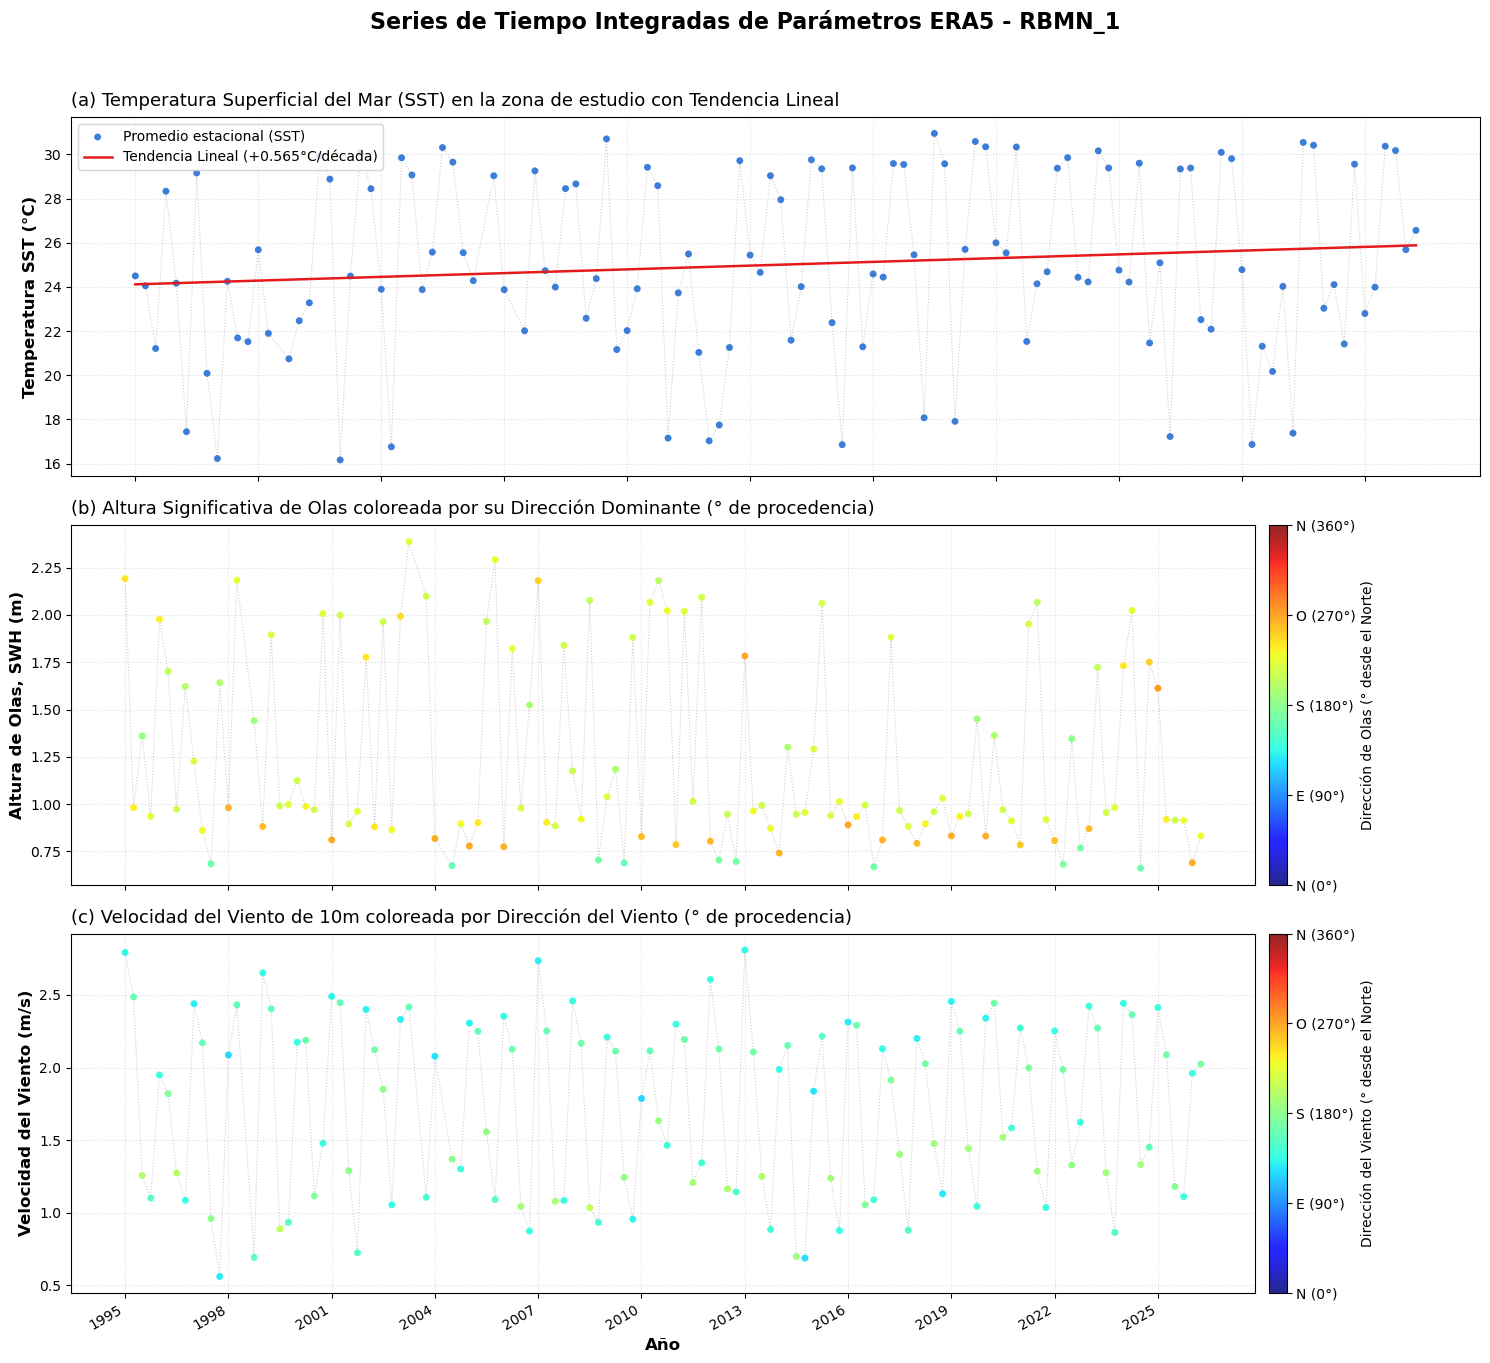

In [47]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os

SITENAME = 'RBMN_1' #Desactivar para cambiar manualmente el titulo del grafico

# Hacer una copia de los datos para visualización
df_plot = df_combined.copy()
df_plot['Fecha_dt'] = pd.to_datetime(df_plot['Fecha'])

# Inicializar figura de matplotlib con 3 paneles (SST, Olas, Viento)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 14), sharex=True)
fig.suptitle(f"Series de Tiempo Integradas de Parámetros ERA5 - {SITENAME}", fontsize=16, fontweight='bold', y=0.97)

# ----------------- PANEL 1: TEMPERATURA (SST vs Tiempo con Tendencia) -----------------
# Eliminar valores nulos para SST
df_sst = df_plot.dropna(subset=['sst_celsius'])

if len(df_sst) > 0:
    # 1. Dibujar línea sutil punteada en el fondo para guiar la secuencia temporal
    ax1.plot(
        df_sst['Fecha_dt'], 
        df_sst['sst_celsius'], 
        linestyle=':', 
        color='#a0a0a0', 
        alpha=0.5, 
        linewidth=0.8,
        zorder=1
    )
    
    # 2. Dibujar los puntos del Scatter
    ax1.scatter(
        df_sst['Fecha_dt'], 
        df_sst['sst_celsius'], 
        color='#1b69d2',      # Azul marino
        s=25, 
        edgecolors='none', 
        alpha=0.85,
        label='Promedio estacional (SST)',
        zorder=2
    )
    
    # 3. Calcular la línea de tendencia lineal usando numpy
    x_dates = df_sst['Fecha_dt']
    x_ord = x_dates.map(lambda d: d.toordinal())
    y_sst = df_sst['sst_celsius']
    
    slope, intercept = np.polyfit(x_ord, y_sst, 1)
    trend_y = slope * x_ord + intercept
    
    # Calcular tasa de cambio por década
    slope_per_decade = slope * 365.2425 * 10
    
    # Graficar línea de tendencia
    ax1.plot(
        x_dates, 
        trend_y, 
        color='#e41a1c',       # Rojo sutil de contraste
        linestyle='-', 
        linewidth=1.8,
        label=f"Tendencia Lineal ({slope_per_decade:+.3f}°C/década)",
        zorder=3
    )
    
    ax1.set_ylabel("Temperatura SST (°C)", fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.4)
    ax1.set_title("(a) Temperatura Superficial del Mar (SST) en la zona de estudio con Tendencia Lineal", fontsize=13, loc='left', pad=8)
    ax1.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.8)
else:
    ax1.text(0.5, 0.5, 'Sin datos de temperatura disponibles', ha='center', va='center')

# ----------------- PANEL 2: OLEJE (Altura vs Tiempo, coloreado por Dirección) -----------------
# Eliminar valores nulos para el oleaje
df_waves = df_plot.dropna(subset=['significant_wave_height_m', 'mean_wave_dir_deg'])

if len(df_waves) > 0:
    # 1. Dibujar línea sutil punteada en el fondo para guiar la secuencia temporal
    ax2.plot(
        df_waves['Fecha_dt'], 
        df_waves['significant_wave_height_m'], 
        linestyle=':', 
        color='#a0a0a0', 
        alpha=0.5, 
        linewidth=0.8, 
        zorder=1
    )
    
    # 2. Dibujar los puntos del Scatter coloreados encima de la línea
    sc1 = ax2.scatter(
        df_waves['Fecha_dt'], 
        df_waves['significant_wave_height_m'], 
        c=df_waves['mean_wave_dir_deg'], 
        cmap='jet',           # El mapa de colores 'jet' provee la transición azul-verde-amarillo-rojo
        vmin=0, 
        vmax=360, 
        s=25,                 # Tamaño de los puntos
        edgecolors='none',    # Sin contorno para una gráfica más limpia
        alpha=0.85,           # Transparencia ligera
        zorder=2              # Colocar encima de la línea
    )
    ax2.set_ylabel("Altura de Olas, SWH (m)", fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle=':', alpha=0.4)
    ax2.set_title("(b) Altura Significativa de Olas coloreada por su Dirección Dominante (° de procedencia)", fontsize=13, loc='left', pad=8)
    
    # Añadir barra de color vertical para la dirección de las olas
    cbar1 = fig.colorbar(sc1, ax=ax2, pad=0.01)
    cbar1.set_label("Dirección de Olas (° desde el Norte)", fontsize=10)
    cbar1.set_ticks([0, 90, 180, 270, 360])
    cbar1.set_ticklabels(['N (0°)', 'E (90°)', 'S (180°)', 'O (270°)', 'N (360°)'])
else:
    ax2.text(0.5, 0.5, 'Sin datos de oleaje disponibles', ha='center', va='center')

# ----------------- PANEL 3: VIENTO (Velocidad vs Tiempo, coloreado por Dirección) -----------------
# Eliminar valores nulos para el viento
df_wind = df_plot.dropna(subset=['wind_speed_m_s', 'wind_dir_deg'])

if len(df_wind) > 0:
    # 1. Dibujar línea sutil punteada en el fondo para guiar la secuencia temporal
    ax3.plot(
        df_wind['Fecha_dt'], 
        df_wind['wind_speed_m_s'], 
        linestyle=':', 
        color='#a0a0a0', 
        alpha=0.5, 
        linewidth=0.8, 
        zorder=1
    )
    
    # 2. Dibujar los puntos del Scatter coloreados encima de la línea
    sc2 = ax3.scatter(
        df_wind['Fecha_dt'], 
        df_wind['wind_speed_m_s'], 
        c=df_wind['wind_dir_deg'], 
        cmap='jet', 
        vmin=0, 
        vmax=360, 
        s=25, 
        edgecolors='none', 
        alpha=0.85,
        zorder=2
    )
    ax3.set_ylabel("Velocidad del Viento (m/s)", fontsize=12, fontweight='bold')
    ax3.set_xlabel("Año", fontsize=12, fontweight='bold')
    ax3.grid(True, linestyle=':', alpha=0.4)
    ax3.set_title("(c) Velocidad del Viento de 10m coloreada por Dirección del Viento (° de procedencia)", fontsize=13, loc='left', pad=8)
    
    # Añadir barra de color vertical para la dirección del viento
    cbar2 = fig.colorbar(sc2, ax=ax3, pad=0.01)
    cbar2.set_label("Dirección del Viento (° desde el Norte)", fontsize=10)
    cbar2.set_ticks([0, 90, 180, 270, 360])
    cbar2.set_ticklabels(['N (0°)', 'E (90°)', 'S (180°)', 'O (270°)', 'N (360°)'])
else:
    ax3.text(0.5, 0.5, 'Sin datos de viento disponibles', ha='center', va='center')

# Formatear marcas del eje temporal X de forma limpia (compartido por ax3)
ax3.xaxis.set_major_locator(mdates.YearLocator(3)) # Marcar cada 3 años
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Guardar figura de alta resolución en la carpeta del proyecto
fig_output_path = os.path.join(OUTPUT_DIR, f'{SITENAME}_series_integradas_climaticas.png')
plt.savefig(fig_output_path, dpi=300, bbox_inches='tight')

print(f"🎨 ¡Gráficas publicables de 3 paneles generadas y guardadas exitosamente como imagen en:")
print(f"   👉 {fig_output_path}")
plt.show()


## COLECCION DE DATOS DE CMEMS PARA NIVEL DEL MAR
El Servicio Marino de Copernicus es un sitio de datos abiertos para la descarga de datos marinos con cobertura mundial, que permite obtener datos actuales e históricos (1950) https://marine.copernicus.eu/access-data/
Para hacer uso, hay que crear una cuenta. La librería copernicusmarine proporciona acceso de manera programática a los datos 

In [ ]:
#!pip install copernicusmarine xarray netcdf4 #Esta librería es necesaria para poder leer los archivos netcdf que se descargan de CMEMS.

**Autentificación, se realiza sólo una vez, las credenciales quedan guardadas para visitas posteriores**

In [24]:
#import copernicusmarine

# 1. Autenticar de forma programática
#copernicusmarine.login(username="TU_USUARIO", password="TU_CONTRASEÑA")

# 2. Validar si la autenticación fue exitosa
#if copernicusmarine.check_credentials_valid():
#    print("✅ ¡Autenticación exitosa! Las credenciales se han guardado correctamente en tu sistema.")
#else:
#    print("❌ Error de autenticación. Por favor, verifica tu usuario y contraseña en Copernicus Marine.")


**Bloque para probar el funcionamiento del acceso**

In [25]:
#import os
#import copernicusmarine

#DATASET_ID = "cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D"
#OUTPUT_DIR = os.path.join(os.getcwd(), 'data', 'RBMN_1')

# Crear directorio si no existe
#os.makedirs(OUTPUT_DIR, exist_ok=True)

#print("⚡ Probando conexión y descarga con Copernicus Marine...")
#try:
#    copernicusmarine.subset(
#        dataset_id=DATASET_ID,
#        variables=["sla"],
#        start_datetime="2020-01-01T00:00:00",
#        end_datetime="2020-01-02T00:00:00", # Solo 1 día de prueba
#        minimum_longitude=-106.0,
#        maximum_longitude=-105.5,
#        minimum_latitude=22.0,
#        maximum_latitude=22.5,
#        output_filename="test_copernicus.nc",
#        output_directory=OUTPUT_DIR,
#        force_download=True
#    )
#    print("🎉 ¡Prueba exitosa! El archivo 'test_copernicus.nc' se descargó correctamente en tu carpeta de datos.")
#except Exception as e:
#    print(f"❌ Error al descargar: {e}")


In [ ]:
import os
import copernicusmarine
import xarray as xr
import numpy as np

c:\Users\PC\anaconda3\envs\coastsat25\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# --- 1. CONFIGURACIÓN ---
# (Las variables de SITENAME y rutas ya están definidas en celdas anteriores)

# 🆕 EXTRAER LÍMITES DINÁMICAMENTE DEL GEOJSON CARGADO EN CELDA ANTERIOR:
geom_type = geojson_data['features'][0]['geometry']['type']

if geom_type == 'Polygon':
    coords = geojson_data['features'][0]['geometry']['coordinates'][0]
elif geom_type == 'MultiPolygon':
    coords = geojson_data['features'][0]['geometry']['coordinates'][0][0]
else:
    raise ValueError(f"Tipo de geometría '{geom_type}' no soportada. Debe ser Polygon o MultiPolygon.")

# Calcular el bounding box (límites)
min_lon = min(c[0] for c in coords)
max_lon = max(c[0] for c in coords)
min_lat = min(c[1] for c in coords)
max_lat = max(c[1] for c in coords)

# 💡 Añadir un pequeño margen de 0.05° (~5 km) 
# para asegurar la cobertura de píxeles gruesos de Copernicus
padding = 0.05
min_lon -= padding
max_lon += padding
min_lat -= padding
max_lat += padding

print(f"📍 Límites geográficos extraídos de {GEOJSON_PATH} (con margen de {padding}°):")
print(f"   Longitud: [{min_lon:.4f}, {max_lon:.4f}]")
print(f"   Latitud:  [{min_lat:.4f}, {max_lat:.4f}]")

# Nombre del archivo NetCDF de salida
NC_OUTPUT_FILE = "copernicus_sealevel.nc"
NC_PATH = os.path.join(OUTPUT_DIR, NC_OUTPUT_FILE) # OUTPUT_DIR ya existe en extract_era5_data.ipynb


📍 Límites geográficos extraídos de proyectos\rbmn_1_mar.geojson (con margen de 0.05°):
   Longitud: [-106.0247, -105.6189]
   Latitud:  [22.2037, 22.5860]


In [ ]:
# --- 2. DESCARGA DEL SUBSET DESDE COPERNICUS ---
# Nota: Usamos el ID del producto de Sea Level Anomaly (008_047)

#SITENAME = 'RBMN_1' #Activar para cambiar manualmente el titulo del grafico
DATASET_ID = "cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D" #https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_L4_MY_008_047/services
print("⬇️ Descargando subset de nivel del mar desde Copernicus Marine...")
copernicusmarine.subset(
    dataset_id=DATASET_ID,
    variables=["sla", "adt"],
    start_datetime="1993-01-01T00:00:00",
    end_datetime="2026-06-30T23:59:59",
    minimum_longitude=min_lon,
    maximum_longitude=max_lon,
    minimum_latitude=min_lat,
    maximum_latitude=max_lat,
    output_filename=NC_OUTPUT_FILE,
    output_directory=os.path.join('data', SITENAME),
    #force_download=True
)
print(f"✅ Archivo NetCDF guardado en: {NC_PATH}")

⬇️ Descargando subset de nivel del mar desde Copernicus Marine...


INFO - 2026-07-08T21:40:42Z - Selected dataset version: "202411"
INFO - 2026-07-08T21:40:42Z - Selected dataset part: "default"
WARNING - 2026-07-08T21:40:42Z - Some of your subset selection [1993-01-01 00:00:00+00:00, 2026-06-30 23:59:59+00:00] for the time dimension exceed the dataset coordinates [1993-01-01 00:00:00+00:00, 2026-01-16 00:00:00+00:00]
INFO - 2026-07-08T21:40:48Z - Total size of the download: 862.38 KB.


✅ Archivo NetCDF guardado en: data\RBMN_1\copernicus_sealevel.nc


In [53]:
# --- 3. PROCESAMIENTO ESPACIAL Y ALINEACIÓN TRIMESTRAL ---
# Abrir el NetCDF con xarray
ds = xr.open_dataset(NC_PATH, engine='h5netcdf')
#ds = xr.open_dataset(NC_PATH)
# Promediar espacialmente sobre la latitud y longitud para tener una serie temporal única
ds_spatial_mean = ds.mean(dim=['latitude', 'longitude'])
# Cargar tu tabla integrada actual de CoastSat + ERA5
df_combined = pd.read_csv(fn_combined)
df_combined['Fecha'] = pd.to_datetime(df_combined['Fecha'])
# Iterar sobre cada fila/trimestre de tu base de datos para calcular el promedio temporal exacto
results_copernicus = []
for idx, row in df_combined.iterrows():
    fecha_dt = row['Fecha']
    year = fecha_dt.year
    month = fecha_dt.month
    
    # Misma lógica estacional que utilizas para ERA5:
    if month == 1:
        start_str = f"{year-1}-12-01"
        end_str = f"{year}-03-01"
    elif month == 4:
        start_str = f"{year}-03-01"
        end_str = f"{year}-06-01"
    elif month == 7:
        start_str = f"{year}-06-01"
        end_str = f"{year}-09-01"
    elif month == 10:
        start_str = f"{year}-09-01"
        end_str = f"{year}-12-01"
    else:
        start_str = f"{year}-{month:02d}-01"
        end_str = f"{year}-{month+3:02d}-01" if month+3 <= 12 else f"{year+1}-01-01"
        
    # Recortar el dataset de Copernicus en este rango estacional
    trimestre_data = ds_spatial_mean.sel(time=slice(start_str, end_str))
    
    # Extraer el promedio temporal
    sla_mean = float(trimestre_data['sla'].mean()) if 'sla' in trimestre_data else np.nan
    adt_mean = float(trimestre_data['adt'].mean()) if 'adt' in trimestre_data else np.nan
    
    results_copernicus.append({
        'Fecha': fecha_dt,
        'sla_copernicus': sla_mean,
        'adt_copernicus': adt_mean
    })
df_copernicus = pd.DataFrame(results_copernicus)
df_copernicus.head(3)

,Fecha,sla_copernicus,adt_copernicus
0,1995-01-01,0.012761,0.639345
1,1995-04-01,-0.068491,0.558092
2,1995-07-01,0.068584,0.695168


In [52]:
# --- 4. INTEGRAR VARIABLES AL CSV PRINCIPAL ---
df_final = pd.merge(df_combined, df_copernicus, on='Fecha', how='left')

# Guardar de nuevo el CSV combinado con Copernicus incluido
df_final.to_csv(fn_combined, index=False)

# Mostrar la confirmación del archivo guardado y la ruta completa
print("----------------------------------------------------------------------------------------------------")
print(f"🔗 3. Tabla final integrada (CoastSat + ERA5 + Copernicus) guardada en:\n   👉 {fn_combined}\n")
print("👀 Muestra de las últimas 5 filas de tu base de datos final acoplada:")

# Mostrar la previsualización de la tabla en Jupyter
display(df_final.tail(5))


----------------------------------------------------------------------------------------------------
🔗 3. Tabla final integrada (CoastSat + ERA5 + Copernicus) guardada en:
   👉 data\RBMN_1\RBMN_1_combined_promedios_estacionales.csv

👀 Muestra de las últimas 5 filas de tu base de datos final acoplada:


,Fecha,tr_rbmn_1,tr_rbmn_2,tr_rbmn_3,tr_rbmn_4,tr_rbmn_5,tr_rbmn_6,tr_rbmn_7,tr_rbmn_8,tr_rbmn_9,...,sst_kelvin,sst_celsius,u_wind_10m,v_wind_10m,wind_speed_m_s,wind_dir_deg,significant_wave_height_m,mean_wave_dir_deg,sla_copernicus,adt_copernicus
118,2025-04-01,93.608856,110.795069,134.869052,131.316950,107.811095,77.896427,87.356070,102.001279,105.264606,...,297.137432,23.987432,2.008303,-0.510050,2.088117,166.716410,0.919200,237.281235,0.016296,0.642880
119,2025-07-01,NaN,76.754631,98.290625,103.125152,90.512478,66.692250,68.948593,71.881054,75.680121,...,303.516679,30.366679,1.177753,-0.072860,1.180290,176.639551,0.915199,212.364243,0.198075,0.824659
120,2025-10-01,73.160911,83.107093,94.181255,98.979140,96.339646,80.637863,87.217027,90.982833,93.075896,...,303.319615,30.169615,0.861457,-0.701398,1.111078,141.057835,0.913915,227.785767,0.140647,0.767230
121,2026-01-01,80.487627,88.827184,98.676727,105.871173,106.955050,95.063546,101.258421,103.191917,106.642091,...,298.835742,25.685742,1.428985,-1.331795,1.960473,138.313135,0.690454,267.322296,0.048165,0.674748
122,2026-04-01,NaN,82.454676,100.351129,109.332164,114.475378,103.334419,106.533789,107.143001,109.340472,...,299.708194,26.558194,1.977990,-0.372118,2.024164,170.087047,0.832822,229.908112,NaN,NaN
